#  Xception Transfer Learning - Image Classification


In [4]:
# 📦 1. Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os


In [ ]:
!pip install gdown
import gdown

file_id = "1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl"
output = "myfile.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Downloading...
From (original): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl
From (redirected): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl&confirm=t&uuid=73fe1b7e-c8cd-4335-9f73-308905769385
To: c:\Users\Jagdish singh\DEEP-LEARNING\Transfer_Learning_img_classfxn\myfile.zip
100%|██████████| 63.9M/63.9M [00:53<00:00, 1.19MB/s]


'myfile.zip'

In [6]:
import zipfile

with zipfile.ZipFile("myfile.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

base_dir = r"C:\Users\Jagdish singh\DEEP-LEARNING\Transfer_Learning_img_classfxn\dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "valid")

img_size = 299
batch_size = 32

# Verify the paths exist before running the generator
if not os.path.exists(train_dir):
    print(f"❌ ERROR: Cannot find train directory at {train_dir}")
else:
    print(f"✅ Found train directory! Proceeding...")

✅ Found train directory! Proceeding...


In [ ]:
# 🔄 3. Data Augmentation Part
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 1275 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


In [11]:
# ✅ 4. Load base model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 56s 1us/step


In [12]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
# 
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
# train_generator.num_classes ==numbers of output neurons
model = Model(inputs=base_model.input, outputs=predictions)


In [14]:
# 🛠️ 6. Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [15]:
# 🚀 7. Train the model (initial training with frozen base)
history = model.fit(
    train_generator,
    epochs=2,
    validation_data=val_generator
)


Epoch 1/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.6682 - loss: 0.6007 - val_accuracy: 0.8819 - val_loss: 0.4793
Epoch 2/2
40/40 ━━━━━━━━━━━━━━━━━━━━ 252s 6s/step - accuracy: 0.8267 - loss: 0.4630 - val_accuracy: 0.9011 - val_loss: 0.3810


Found 1275 images belonging to 2 classes.
Found 364 images belonging to 2 classes.
40/40 ━━━━━━━━━━━━━━━━━━━━ 276s 7s/step - accuracy: 0.8510 - loss: 0.4260 - val_accuracy: 0.8984 - val_loss: 0.3723


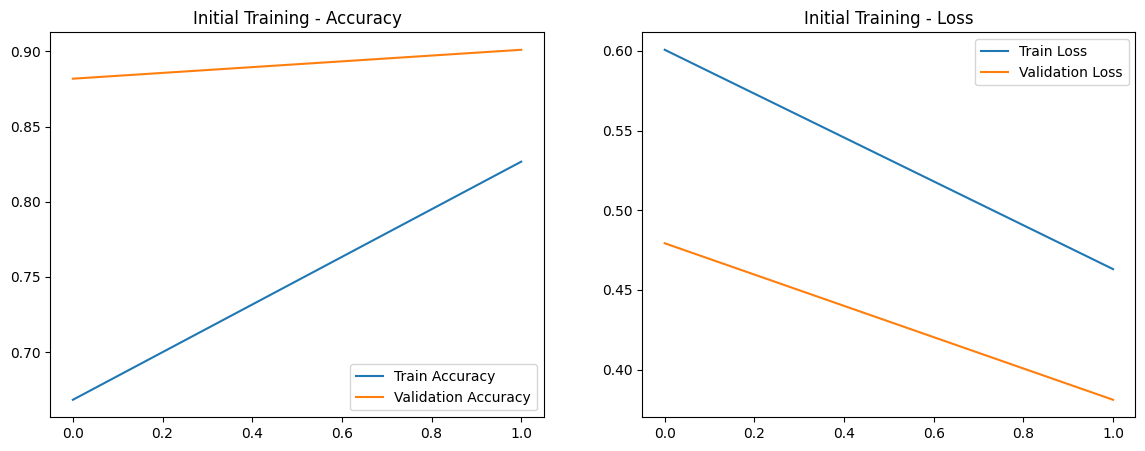

In [29]:
import os

# Updated to the folder name shown in your error
base_dir = r"C:\Users\Jagdish singh\DEEP-LEARNING\Transfer_Learning_img_classfxn\Rotten-apples-detection-5\dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "valid")

# Re-run the generators so they point to the NEW paths
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)
base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
fine_tune_history = model.fit(
     train_generator,
    epochs=1,
    validation_data=val_generator
 )

def plot_history(history, title):
    acc = fine_tune_history.history['accuracy']
    val_acc = fine_tune_history.history['val_accuracy']
    loss = fine_tune_history.history['loss']
    val_loss = fine_tune_history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.show()
    
plot_history(fine_tune_history, "Fine Tuning")
# plot_history(history, "Initial Training")


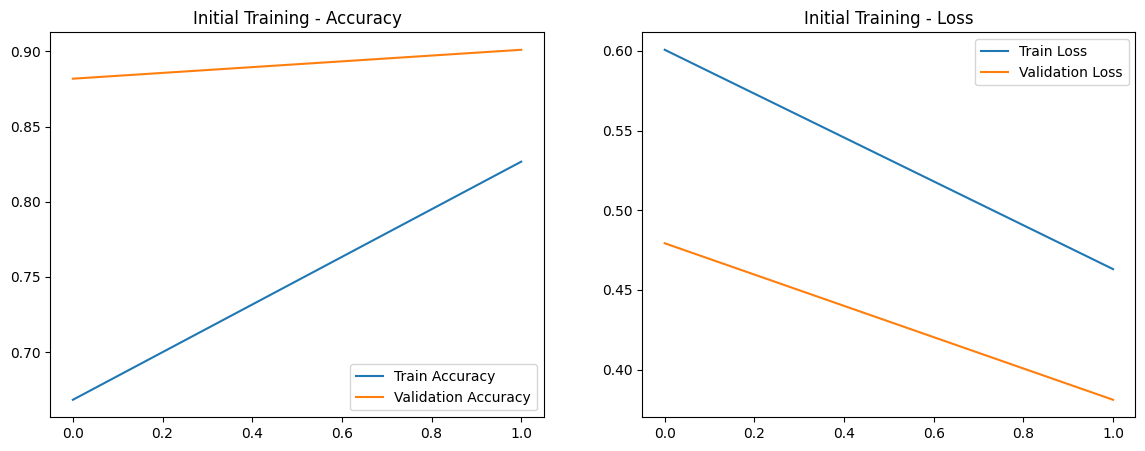

In [16]:
# 📊 9. Plot training history
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.show()

plot_history(history, "Initial Training")
#plot_history(fine_tune_history, "Fine Tuning")


In [19]:
# 💾 10. Save model
model.save("xception_transfer_learning_model.h5")


In [20]:

model.save("xception_transfer_learning_model.keras")


In [21]:
from tensorflow.keras.models import load_model

model = load_model("xception_transfer_learning_model.keras")

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def predict_image(model, image_path):
    img = load_img(image_path, target_size=(299, 299))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.xception.preprocess_input(img_array)

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)
    class_indices = {v: k for k, v in train_generator.class_indices.items()}
    return class_indices[predicted_class[0]]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Predicted Label: daisy


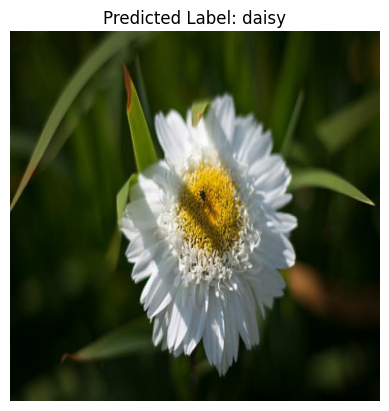

Predicted Label: daisy


In [27]:
image_path = r"C:\Users\Jagdish singh\DEEP-LEARNING\Transfer_Learning_img_classfxn\dataset\test\daisy\14613443462_d4ed356201_jpg.rf.76462b3f0cb5ca5a0b4b7c9894feb91c.jpg"
predicted_label = predict_image(model, image_path)
print("Predicted Label:", predicted_label)

img = tf.keras.utils.load_img(image_path)
plt.imshow(img)
plt.title(f"Predicted Label: {predicted_label}")
plt.axis("off") # Hides the x and y axis numbers
plt.show()

print("Predicted Label:", predicted_label)

In [25]:
# Updated for your Windows machine
image_path = r"C:\Users\Jagdish singh\DEEP-LEARNING\Transfer_Learning_img_classfxn\dataset\test\dandelion\14060367700_fe87e99b6a_m_jpg.rf.eaf8222cde370b2ebb4d6a1378ec07b1.jpg"

# Run prediction
predicted_label = predict_image(model, image_path)

print(f"Predicted Label: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Predicted Label: dandelion


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


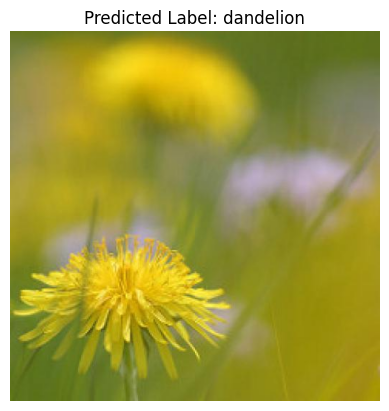

Predicted Label: dandelion


In [26]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Set the correct Windows path
image_path = r"C:\Users\Jagdish singh\DEEP-LEARNING\Transfer_Learning_img_classfxn\dataset\test\dandelion\14060367700_fe87e99b6a_m_jpg.rf.eaf8222cde370b2ebb4d6a1378ec07b1.jpg"

# 2. Get the prediction
predicted_label = predict_image(model, image_path)

# 3. Load and show the image
img = tf.keras.utils.load_img(image_path)
plt.imshow(img)
plt.title(f"Predicted Label: {predicted_label}")
plt.axis("off") # Hides the x and y axis numbers
plt.show()

print("Predicted Label:", predicted_label)